In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the CSV file
# The keys in this file have been corrected to 2050 and 2090
file_path = "data/FullJoin3_with_climate_ratings-proofed.csv"
df = pd.read_csv(file_path)

# Map the long column names to shorthand versions for easier coding
column_mapping = {
    'climate_rating_current_sheet': 'rating_2025_current',
    'climate_rating_emissions_limited_2050': 'rating_2050_limited',
    'climate_rating_business_as_usual_2090': 'rating_2090_bau',
    'climate_rating_bau_plus_1degree_2090': 'rating_2090_heat_sink'
}
df = df.rename(columns=column_mapping)

# Display first few rows to confirm keys and data structure
display(df.head())

,AccNoFull,ItemAccNoFull,LocationName,LocationCoordY,LocationCoordX,LifeForm,Family,Genus,GenusSpecies,ItemLocationCode,...,ItemType,IUCNRedList,NationalRedList,RegionalRedList,Locality,LocalityFull,rating_2050_limited,rating_2025_current,rating_2090_bau,rating_2090_heat_sink
0,1999-0404,1999-0404.01,Contemporary Garden,-123.246025,49.253365,Shrub,Oleaceae,Abeliophyllum,Abeliophyllum distichum,1C01,...,Planting,NaN,NaN,NaN,NaN,NaN,9.0,11.0,3.0,3.0
1,2014-0168,2014-0168.01,Asian Garden,-123.251150,49.253642,Shrub,Oleaceae,Abeliophyllum,Abeliophyllum distichum,3AAF,...,Planting,NaN,NaN,NaN,NaN,NaN,9.0,11.0,3.0,3.0
2,1983-0427,1983-0427.01,Alpine Garden,-123.246104,49.253650,Shrub,Pinaceae,Abies,Abies koreana,LAS4,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,5.0,5.0
3,1987-0067,1987-0067.01,Alpine Garden,-123.246737,49.254134,Shrub,Pinaceae,Abies,Abies balsamea,LNA3,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,3.0,3.0
4,1987-0067,1987-0067.02,Alpine Garden,-123.246714,49.254241,Shrub,Pinaceae,Abies,Abies balsamea,LNA1,...,Planting,NaN,NaN,NaN,NaN,NaN,6.0,9.0,3.0,3.0


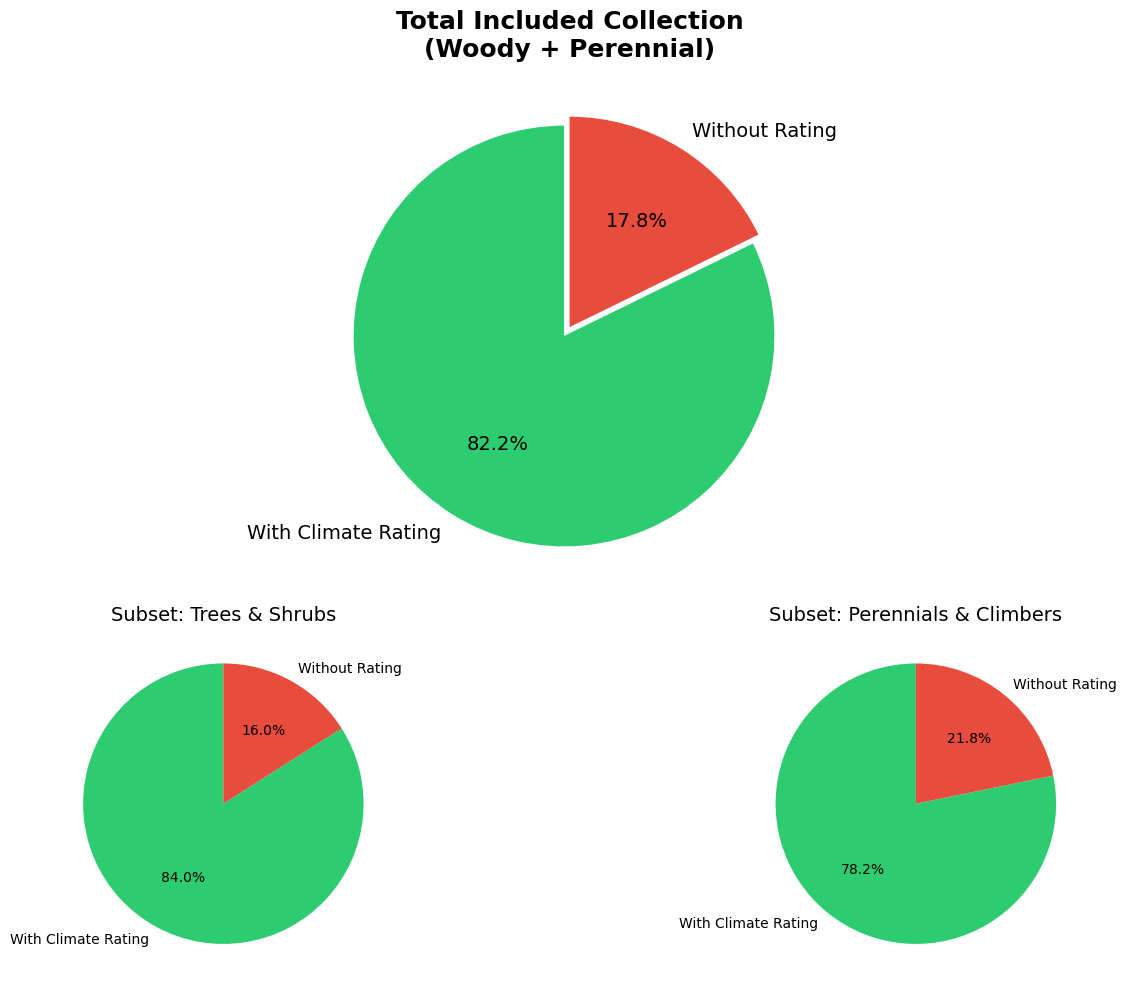

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Filter the dataset for included lifeforms only
included_lifeforms = ['Tree', 'Shrub', 'Shrub or Tree', 'Herbaceous Perennial', 'Climber_Liana_Vine']
df_filtered = df[df['LifeForm'].isin(included_lifeforms)].copy()

# 2. Define our target subsets
tree_shrub_list = ['Tree', 'Shrub', 'Shrub or Tree']
perennial_list = ['Herbaceous Perennial', 'Climber_Liana_Vine']

tree_shrub_df = df_filtered[df_filtered['LifeForm'].isin(tree_shrub_list)]
perennial_df = df_filtered[df_filtered['LifeForm'].isin(perennial_list)]

# 3. Helper function for counts
climate_cols = ['rating_2025_current', 'rating_2050_limited', 'rating_2090_bau', 'rating_2090_heat_sink']

def get_counts(data):
    # Counts how many rows have at least one climate rating
    with_rating = data[climate_cols].notna().any(axis=1).sum()
    return [with_rating, len(data) - with_rating]

# 4. Visualization
labels = ["With Climate Rating", "Without Rating"]
colors = ['#2ecc71', '#e74c3c']

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1])

# Large Pie: Total Included Collection
ax0 = plt.subplot(gs[0, :])
ax0.pie(get_counts(df_filtered), labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=colors, explode=(0.05, 0), textprops={'fontsize': 14})
ax0.set_title("Total Included Collection\n(Woody + Perennial)", fontsize=18, fontweight='bold')

# Small Pie: Woody Subset (Tree/Shrub)
ax1 = plt.subplot(gs[1, 0])
ax1.pie(get_counts(tree_shrub_df), labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title("Subset: Trees & Shrubs", fontsize=14)

# Small Pie: Perennial/Climber Subset
ax2 = plt.subplot(gs[1, 1])
ax2.pie(get_counts(perennial_df), labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title("Subset: Perennials & Climbers", fontsize=14)

plt.tight_layout()
plt.show()


Families experiencing the most significant decline in suitability (2025 vs 2090 Heat Sink):


,rating_2025_current,rating_2090_heat_sink,suitability_drop
Family,,,
Lentibulariaceae,11.00,2.00,9.00
Typhaceae,11.00,2.00,9.00
Juncaceae,10.00,2.50,7.50
Violaceae,10.38,3.31,7.08
Polygalaceae,9.00,2.00,7.00
Tofieldiaceae,9.00,2.00,7.00
Gentianaceae,9.24,2.71,6.53
Linaceae,10.00,3.50,6.50
Montiaceae,9.73,3.67,6.07


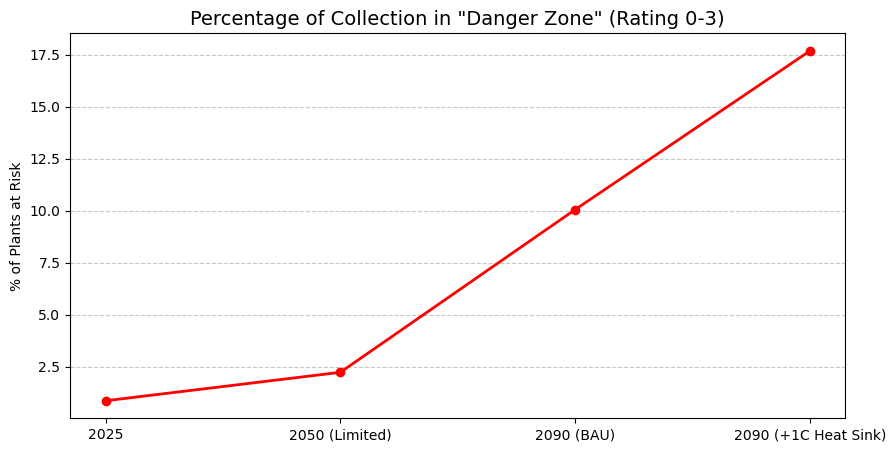

In [12]:
# 1. Calculate Average Ratings per Family for comparison
avg_ratings = df_filtered.groupby('Family')[['rating_2025_current', 'rating_2090_heat_sink']].mean()

# 2. Calculate the 'Suitability Drop'
avg_ratings['suitability_drop'] = avg_ratings['rating_2025_current'] - avg_ratings['rating_2090_heat_sink']

# 3. Apply the 2-decimal rounding rule
avg_ratings = avg_ratings.round(2)

print("Families experiencing the most significant decline in suitability (2025 vs 2090 Heat Sink):")
display(avg_ratings.sort_values('suitability_drop', ascending=False).head(10))

# 4. Calculate overall garden risk percentage across scenarios
scenarios = {
    '2025': 'rating_2025_current',
    '2050 (Limited)': 'rating_2050_limited',
    '2090 (BAU)': 'rating_2090_bau',
    '2090 (+1C Heat Sink)': 'rating_2090_heat_sink'
}

risk_trend = {}
for label, col in scenarios.items():
    pct = (df_filtered[col] <= 3).mean() * 100
    risk_trend[label] = round(pct, 2)

# Visualization of the migration to risk
plt.figure(figsize=(10, 5))
plt.plot(list(risk_trend.keys()), list(risk_trend.values()), marker='o', color='red', linewidth=2)
plt.title('Percentage of Collection in "Danger Zone" (Rating 0-3)', fontsize=14)
plt.ylabel('% of Plants at Risk')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 1. Generate family-level statistics for the 2090 Heat Sink scenario
threshold = 3
family_stats = df_filtered.dropna(subset=['rating_2090_heat_sink']).groupby('Family').agg(
    total_members=('Family', 'count'),
    mean_2090_rating=('rating_2090_heat_sink', 'mean'),
    at_risk_count=('rating_2090_heat_sink', lambda x: (x <= threshold).sum())
)

# 2. Calculate percentage at risk
family_stats['percent_at_risk'] = (family_stats['at_risk_count'] / family_stats['total_members'] * 100).round(2)
family_stats['mean_2090_rating'] = family_stats['mean_2090_rating'].round(2)

# 3. Filter for 'Red Flags': Small families (< 5 members) with high risk (> 50% at risk)
red_flags = family_stats[(family_stats['total_members'] < 5) & (family_stats['percent_at_risk'] > 50)].copy()

print(f"CONSERVATION RED FLAGS: {len(red_flags)} small/monotypic families at high risk of local extinction.")
display(red_flags.sort_values(by=['percent_at_risk', 'total_members'], ascending=[False, True]))

In [ ]:
# Filter for observations that are trees or shrubs
tree_shrub_df = df[df['LifeForm'].str.lower().isin(['tree', 'shrub'])]

# Calculate proportions for trees and shrubs having climate ratings
tree_shrub_with_rating = tree_shrub_df['HasClimateRating'].mean()
tree_shrub_without_rating = 1 - tree_shrub_with_rating

# Prepare a readable result
tree_shrub_result = pd.DataFrame({
    "Category": ["With Climate Rating", "Without Climate Rating"],
    "Proportion": [tree_shrub_with_rating, tree_shrub_without_rating]
})
display(tree_shrub_result)

# Filter for observations classified as herbaceous
herbaceous_df = df[df['LifeForm'].str.lower().str.contains('herbaceous')]

# Calculate proportions for herbaceous material having climate ratings
herbaceous_with_rating = herbaceous_df['HasClimateRating'].mean()
herbaceous_without_rating = 1 - herbaceous_with_rating

# Prepare a readable result
herbaceous_result = pd.DataFrame({
    "Category": ["With Climate Rating", "Without Climate Rating"],
    "Proportion": [herbaceous_with_rating, herbaceous_without_rating]
})
display(herbaceous_result)

# Top 10 family with largest change in climate rating

In [ ]:
# Calculate the change in climate ratings over time (2025 to 2080)
climate_ratings_trimmed = df[['Family', 
                              'climate_rating_current_sheet', 
                              'climate_rating_emissions_limited_2040', 
                              'climate_rating_business_as_usual_2080']].dropna()

# Calculate changes in climate ratings
climate_ratings_trimmed['Change_2025_to_2040'] = climate_ratings_trimmed['climate_rating_emissions_limited_2040'] - climate_ratings_trimmed['climate_rating_current_sheet']
climate_ratings_trimmed['Change_2040_to_2080'] = climate_ratings_trimmed['climate_rating_business_as_usual_2080'] - climate_ratings_trimmed['climate_rating_emissions_limited_2040']
climate_ratings_trimmed['Total_Change_2025_to_2080'] = climate_ratings_trimmed['climate_rating_business_as_usual_2080'] - climate_ratings_trimmed['climate_rating_current_sheet']

# Aggregate by plant family to see mean directional change and variation within families
family_trends = climate_ratings_trimmed.groupby('Family').agg({
    'Change_2025_to_2040': ['mean', 'std'],
    'Change_2040_to_2080': ['mean', 'std'],
    'Total_Change_2025_to_2080': ['mean', 'std']
}).reset_index()

# Flatten column names
family_trends.columns = ['Family', 'Mean_Change_2025_to_2040', 'Std_Change_2025_to_2040', 
                         'Mean_Change_2040_to_2080', 'Std_Change_2040_to_2080', 
                         'Mean_Total_Change_2025_to_2080', 'Std_Total_Change_2025_to_2080']

# Sort by total mean change to highlight rapidly changing families
family_trends_sorted = family_trends.sort_values(by='Mean_Total_Change_2025_to_2080', ascending=False)

# Display the top families with the largest changes
display(family_trends_sorted.head(10))


In [ ]:
# Determine portions of observations moving into the 0-3 climate rating zone
portion_below_threshold_2040 = (climate_ratings_trimmed['climate_rating_emissions_limited_2040'] <= 3).mean()
portion_below_threshold_2080 = (climate_ratings_trimmed['climate_rating_business_as_usual_2080'] <= 3).mean()

# Prepare a readable result
climate_threshold_result = pd.DataFrame({
    "Year": ["2040", "2080"],
    "Proportion <= 3": [portion_below_threshold_2040*100, portion_below_threshold_2080*100]
})
display(climate_threshold_result)

# Family Over-representation 

The overrepresentation factor measures how much more common a plant family is in the subset of observations moving into the 0-3 climate rating zone (by 2080) compared to its overall representation in the dataset.

### How it's calculated:
$$
\text{Overrepresentation Factor} =
\frac{\text{Overall proportion of family in the dataset}}{\text{Proportion of family in 0-3 climate rating}}
$$

 
### Interpreting the values:
A value of 1 means the family is equally represented in the 0-3 climate rating as it is in the overall dataset.
A value greater than 1 indicates overrepresentation, meaning the family is disproportionately affected and more common in the 0-3 zone compared to its normal frequency.
For example, an overrepresentation factor of 8 (like we saw with families such as Juncaceae or Typhaceae) means that these families are 8 times more common in the group of plants likely to face unsuitable conditions by 2080 than expected based on their overall presence.

The overrepresentation factor might help identify plant families that are disproportionately vulnerable to climate change.

In [ ]:
# Filter observations that move into the 0-3 climate rating zone in 2080
below_threshold_2080 = climate_ratings_trimmed[climate_ratings_trimmed['climate_rating_business_as_usual_2080'] <= 3]

# Calculate family proportions within the below-threshold subset
family_counts_below_threshold = below_threshold_2080['Family'].value_counts(normalize=True)

# Calculate overall family proportions in the full dataset
overall_family_proportions = climate_ratings_trimmed['Family'].value_counts(normalize=True)

# Compare the proportion of each family in the below-threshold subset to its overall representation
overrepresentation = (family_counts_below_threshold / overall_family_proportions).sort_values(ascending=False)

# Display the top overrepresented families
display(overrepresentation.head(10))